In [1]:
from datetime import datetime
from pathlib import Path

from viberank.datasets.hmls_dataloader import HMISPairwiseDataLoader
from viberank.experiments.pairwise_comparisons import PairwiseExperimentRunner
from viberank.utils.logging import JSONLResponseLogger
from viberank.comparators.dummy import DummyComparator

In [2]:
config_path = Path("../configs/datasets/hmls.yaml")

dataloader = HMISPairwiseDataLoader.from_yaml(config_path)
dataloader.prepare()

run_id = datetime.now().strftime("dummy_vispdat_%Y%m%d_%H%M%S")
log_path = dataloader.config.responses_dir / f"{run_id}.jsonl"

logger = JSONLResponseLogger(
    log_path=log_path,
    flush_every=1,
    store_prompts=True,
)

comp = DummyComparator(
    **dataloader.get_comparator_kwargs(),
    num_samples=dataloader.config.run_settings.get("repeats_per_ordered_pair", 10),
    logger=logger,
    rng_seed=42,
)

runner = PairwiseExperimentRunner(
    dataloader=dataloader,
    logger=logger,
    comparator=comp,
    run_id=run_id,
    model_name="dummy",
    prompt_version=dataloader.config.prompt_filename,
)

win_matrix = runner.run()

In [3]:
from viberank.utils.plotting.pairwise_hmls import make_heatmap_for_run

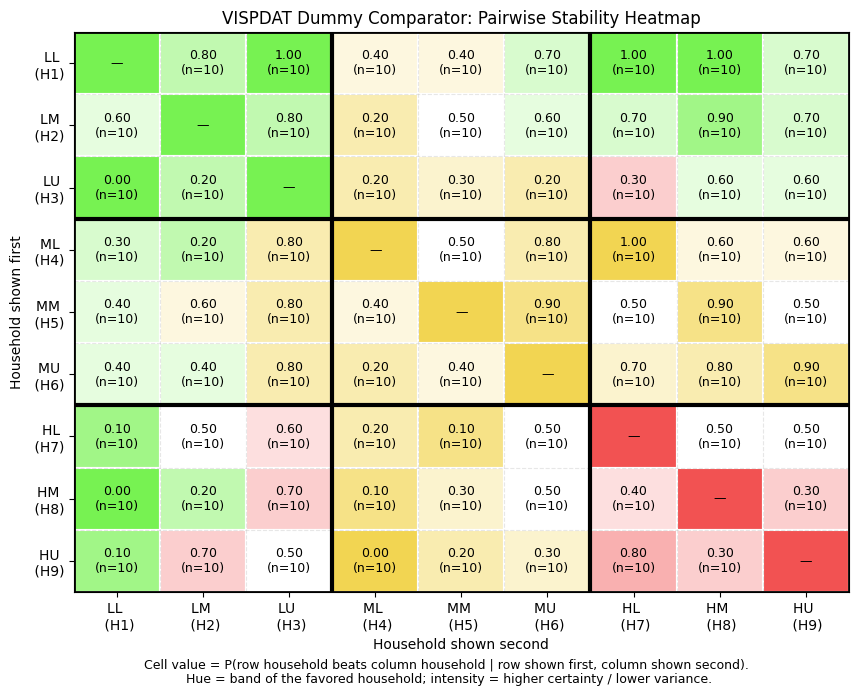

In [5]:
dataset_name = "VISPDAT"

raw_path = Path("/Users/gaurabpokharel/Library/CloudStorage/Box-Box/WashU-ICA-SFT-Working Folder - shared/Sandboxes/Gaurab Pokharel/VibeRank/raw/hmls")
processed_path = Path("/Users/gaurabpokharel/Library/CloudStorage/Box-Box/WashU-ICA-SFT-Working Folder - shared/Sandboxes/Gaurab Pokharel/VibeRank/processed/pairwise_comparisons/hmls")

selected_csv = processed_path / dataset_name / "selected_households.csv"
log_path = raw_path / dataset_name / "responses" / "dummy_vispdat_20260402_124634.jsonl"


selected_df, trials_df, prob_matrix, n_matrix = make_heatmap_for_run(
    selected_csv=selected_csv,
    log_path=log_path,
    title="VISPDAT Dummy Comparator: Pairwise Stability Heatmap",
    save_path=raw_path / "VISPDAT" / "responses" / "vispdat_dummy_heatmap.png",
)